In [1]:
import sys
import os

import xarray as xr
import rioxarray
import sys
sys.path.insert(1, '../Tools/')
import argparse 
import os
import sys
import xarray as xr
import mypythonlib
from mypythonlib import myfunctions 
import geopandas as gpd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# S1 Change-Detection-Tile Processing Pipeline

Description: This code processes a dataset through several steps including loading, cleaning, renaming, and reprojecting.

1. Load dataset with filename

2. Define the Coordinate Reference Systems (CRS) for the azimuthal equidistant and WGS 84 projections.

3. Define the variables to drop

4. Drop 'x_bnds' and 'y_bnds' if they exist in the dataset

5. Update the list of variables after dropping

6. Rename 'unnamed' variable to 'layer' if it exists

7. Rename 'X' and 'Y' variables to 'x' and 'y' if both exist

8. Update the list of variables after renaming

9. Write the azimuthal equidistant CRS to the dataset

10. Reproject the dataset to the WGS 84 projection (EPSG:4326)

In [2]:
# Define variables for dynamic data directory construction
input_file = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/s1_change_detection_northamerica/EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc"
filename = os.path.basename(input_file)
print("Filename:", filename)

Filename: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc


In [31]:
import os

# Step 1: Load dataset with filename
print("Step  1: Load data from:", filename)
filename = os.path.basename(input_file)
dataset = xr.open_dataset(input_file)
print("     Dataset loaded successfully.")
# Get a list of variable names in the dataset
variables = list(dataset.variables)
print("     Variables in the dataset:", variables)

# Step 2: Define the Coordinate Reference Systems (CRS)
print("Step 2: Define the Coordinate Reference Systems (CRS)")
crs_azimuthal_equidistant = "+proj=aeqd +lat_0=52 +lon_0=-97.5 +x_0=8264722.17686 +y_0=4867518.35323 +datum=WGS84 +units=m +no_defs"
crs_wgs84 = 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]'


# Step 3: Define the variables to drop
print("Step 3: Define the variables to drop")
variables_to_remove = ["x_bnds", "y_bnds"]

# Step 4: Drop 'x_bnds' and 'y_bnds' if they exist in the dataset
print("Step 4: Drop 'x_bnds' and 'y_bnds' if they exist in the dataset")
for variable in variables_to_remove:
    if variable in dataset.variables:
        dataset = dataset.drop_vars(variable)
print("     Variables 'x_bnds' and 'y_bnds' dropped successfully.")

# Step 5: Update the list of variables after dropping
print("Step 5: Update the list of variables after dropping")
current_variable_list = list(dataset.variables)

# Step 6: Rename 'unnamed' variable to 'layer' if it exists
print("Step 6: Rename 'unnamed' variable to 'layer' if it exists")
if 'unnamed' in dataset.variables:
    dataset = dataset.rename({'unnamed': 'layer'})
    print("     Variable 'unnamed' renamed to 'layer'.")
else:
    print("     No variable named 'unnamed' found.")

# Step 7: Rename 'X' and 'Y' variables to 'x' and 'y' if both exist
print("Step 7: Rename 'X' and 'Y' variables to 'x' and 'y' if both exist")
if 'X' in dataset.variables and 'Y' in dataset.variables:
    dataset = dataset.rename({'X': 'x', 'Y': 'y'})
    print("     Variables 'X' and 'Y' renamed to 'x' and 'y'.")
else:
    print("     No variables named 'X' and 'Y' found.")

# Step 8: Update the list of variables after renaming
print("Step 8: Update the list of variables after renaming")
current_variable_list = list(dataset.variables)
print("     Current variables:", current_variable_list)

# Step 9: Write the azimuthal equidistant CRS to the dataset
print("Step 9: Write the azimuthal equidistant CRS to the dataset")
dataset.rio.write_crs(crs_azimuthal_equidistant, inplace=True)

# Step 10: Reproject the dataset to the WGS 84 projection (EPSG:4326)
print("Step 10: Reproject the dataset to the WGS 84 projection (EPSG:4326)")
dataset_wgs84 = dataset.rio.reproject(crs_wgs84)

dataset_wgs84

Step  1: Load data from: EQUI7_NA020M_E084N024T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc
     Dataset loaded successfully.
     Variables in the dataset: ['x_bnds', 'x', 'y_bnds', 'y', 'unnamed']
Step 2: Define the Coordinate Reference Systems (CRS)
Step 3: Define the variables to drop
Step 4: Drop 'x_bnds' and 'y_bnds' if they exist in the dataset
     Variables 'x_bnds' and 'y_bnds' dropped successfully.
Step 5: Update the list of variables after dropping
Step 6: Rename 'unnamed' variable to 'layer' if it exists
     Variable 'unnamed' renamed to 'layer'.
Step 7: Rename 'X' and 'Y' variables to 'x' and 'y' if both exist
     No variables named 'X' and 'Y' found.
Step 8: Update the list of variables after renaming
     Current variables: ['x', 'y', 'layer']
Step 9: Write the azimuthal equidistant CRS to the dataset
Step 10: Reproject the dataset to the WGS 84 projection (EPSG:4326)


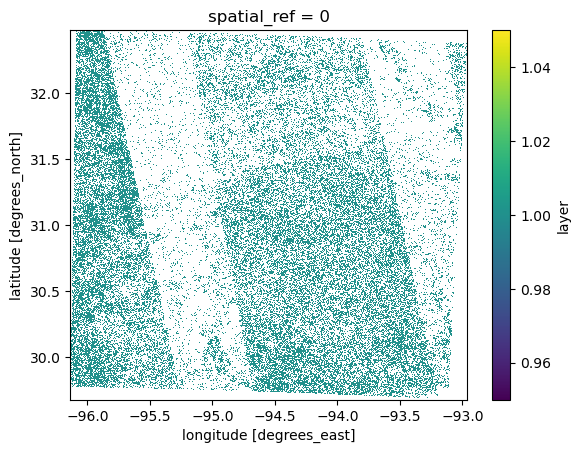

In [45]:
dataset_wgs84['layer'].plot()

# Apply TreeCanopyCover Map 2017

In [52]:
import xarray as xr
import rioxarray

# Step 1: Defining the NetCDF file
print("Step 1: Defining the NetCDF file...")
spatial_extent = dataset_wgs84

# Step 2: Define the path to the TIF file
print("Step 2: Defining the path to the TIF file...")
TCC_path_2017 = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/NLCD_TCC_version_2021.4/nlcd_tcc_conus_2017_v2021-4/nlcd_tcc_conus_2017_v2021_4_res_20_epsg_4326_region_8.tif"

# Step 3: Open the entire TIF file
print("Step 3: Opening the entire TIF file...")
tcc_2017 = rioxarray.open_rasterio(TCC_path_2017, decode_coords="all", masked=True)

# Step 4: Extract the spatial extent from the NetCDF file
print("Step 4: Extracting spatial extent from the NetCDF file...")
min_lon, max_lon = spatial_extent['x'].min(), spatial_extent['x'].max()
min_lat, max_lat = spatial_extent['y'].min(), spatial_extent['y'].max()

# Step 5: Select the subset using xarray's indexing capabilities
print("Step 5: Selecting the subset using xarray's indexing capabilities...")
subset = tcc_2017.sel(x=slice(min_lon, max_lon), y=slice(max_lat, min_lat))

# Step 6: Calculate the minimum value of the subset
print("Step 6: Calculating the minimum value of the subset...")
min_value = subset.min() if not subset.isnull().all() else 0

# Step 7: Calculate the normalized subset
print("Step 7: Calculating the normalized subset...")
normalized_subset = (subset - min_value) / (subset.max() - min_value) if subset.max() != min_value else subset

# Step 8: Set values equal to 1 to 0
print("Step 8: Setting values equal to 1 to 0...")
normalized_subset = normalized_subset.where(normalized_subset != 1, 0)

# Step 9: Reindex the normalized subset to match the coordinates of dataset_wgs84
print("Step 9: Reindexing the normalized subset...")
normalized_subset = normalized_subset.reindex(x=spatial_extent.coords['x'], method='nearest')
normalized_subset = normalized_subset.reindex(y=spatial_extent.coords['y'], method='nearest')

# Step 10: Apply masking based on the normalized subset
print("Step 10: Applying masking based on the normalized subset...")
masked_mc = spatial_extent.where(normalized_subset > 0.3, 0).fillna(0)

masked_mc


Step 1: Defining the NetCDF file...
Step 2: Defining the path to the TIF file...
Step 3: Opening the entire TIF file...
Step 4: Extracting spatial extent from the NetCDF file...
Step 5: Selecting the subset using xarray's indexing capabilities...
Step 6: Calculating the minimum value of the subset...
Step 7: Calculating the normalized subset...
Step 8: Setting values equal to 1 to 0...
Step 9: Reindexing the normalized subset...
Step 10: Applying masking based on the normalized subset...


<xarray.Dataset>
Dimensions:      (y: 14544, x: 16477, band: 1)
Coordinates:
  * x            (x) float64 -96.14 -96.14 -96.14 ... -92.96 -92.96 -92.96
  * y            (y) float64 32.48 32.48 32.48 32.48 ... 29.68 29.68 29.67 29.67
    spatial_ref  int64 0
  * band         (band) int64 1
Data variables:
    layer        (y, x, band) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    _FillValue:  9.96921e+36

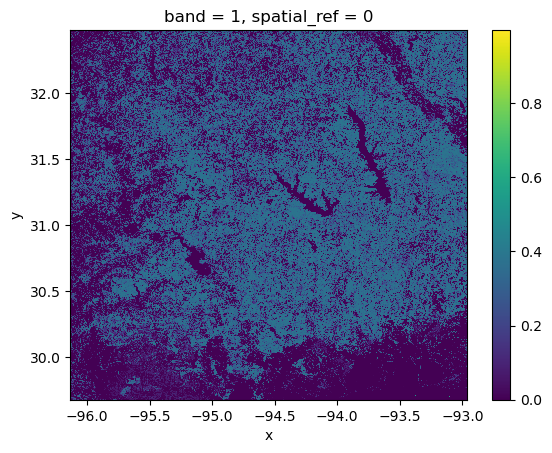

In [38]:
normalized_subset.plot()

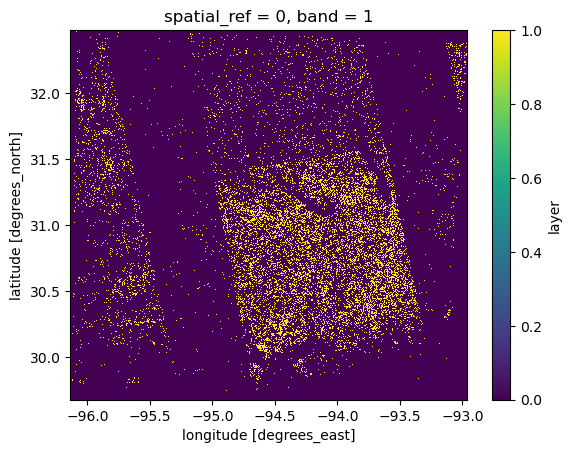

In [50]:
masked_mc.layer.plot()